In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import setup_plotting, switch_cwd_to_root

switch_cwd_to_root()

figure_dir = "figures/revision/figure-1"
setup_plotting(figure_dir, display_dpi=300, save_dpi=300)

import os

import matplotlib.pyplot as plt
import scanpy as sc

from spatial_tcr.tcr import get_tcr_genes
from spatial_tcr.utils import (
    aggregate_gene_expression,
)

In [2]:
data_dir = "data/xenium/processed"
path = f"{data_dir}/06.2-kidney_tcr_filtered.h5ad"
adata = sc.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 510139 × 431
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate'
    var: 'n_cells_by_co

In [3]:
av_genes, bv_genes, dv_genes, gv_genes, tv_genes = get_tcr_genes(adata)
trv_mapping = {
    "TRAV": av_genes,
    "TRBV": bv_genes,
    "TRDV": dv_genes,
    "TRGV": gv_genes,
}

ad_merged = aggregate_gene_expression(adata, trv_mapping)
ad_merged.layers["counts"] = ad_merged.X.copy()

Found 35 TRAV genes, 31 TRBV genes, 3 TRDV genes, 14 TRGV genes


In [4]:
sc.pp.normalize_total(ad_merged)
sc.pp.log1p(ad_merged)

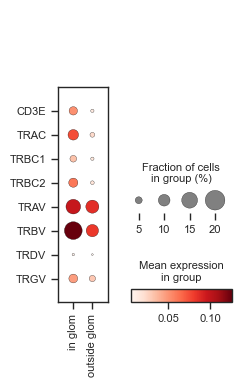

In [5]:
var_names = [
    # "CD3D",
    "CD3E",
    # "CD3G",
    "TRAC",
    "TRBC1",
    "TRBC2",
    "TRAV",
    "TRBV",
    "TRDV",
    "TRGV",
]
ad_merged.obs["in_glom"] = ad_merged.obs["in_glom"].astype(str)
fig = sc.pl.dotplot(ad_merged, var_names, groupby="in_glom", swap_axes=True, show=False)

# dp = sc.pl.dotplot(
#     ad_merged,
#     var_names,
#     groupby="cell_type_l0",
#     return_fig=True,
#     # standard_scale="var",
#     cmap="Reds",
#     swap_axes=True,
# )
# dp.add_totals().style(dot_edge_color="black", dot_edge_lw=0.5).show()

# Update x-axis labels
fig["mainplot_ax"].set_xticklabels(["in glom", "outside glom"])

plt.savefig(
    os.path.join(figure_dir, "tcr_distribution_glom.pdf"), dpi=300, bbox_inches="tight"
)